In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 13,
    "figure.figsize": (7, 5),
})

In [71]:
def mvn_pdf_grid(xs, ys, mu, Sigma):
    X, Y = np.meshgrid(xs, ys)
    pos = np.stack([X, Y], axis=-1)

    Sigma_inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))

    diff = pos - mu
    quad = (
        diff[..., 0] * (Sigma_inv[0, 0] * diff[..., 0] + Sigma_inv[0, 1] * diff[..., 1])
        + diff[..., 1] * (Sigma_inv[1, 0] * diff[..., 0] + Sigma_inv[1, 1] * diff[..., 1])
    )
    return norm * np.exp(-0.5 * quad)


def sample_gmm(n, mus, Sigmas, weights, rng):
    k = len(mus)
    comps = rng.choice(k, size=n, p=weights)

    xs = np.zeros((n, 2))
    for i in range(k):
        idx = np.where(comps == i)[0]
        if len(idx) > 0:
            xs[idx] = rng.multivariate_normal(
                mus[i], Sigmas[i], size=len(idx)
            )

    return xs, comps


def gmm_pdf_grid(xs, ys, mus, Sigmas, weights):
    Z = np.zeros((len(ys), len(xs)))
    for w, mu, S in zip(weights, mus, Sigmas):
        Z += w * mvn_pdf_grid(xs, ys, mu, S)
    return Z



def map_regions(xs, ys, mus, Sigmas, weights):
    """
    Compute MAP class index over a grid.
    Assumes Gaussian components.
    """
    X, Y = np.meshgrid(xs, ys)
    grid = np.stack([X, Y], axis=-1)  # (H,W,2)

    K = len(mus)
    log_probs = []

    for k in range(K):
        mu = mus[k]
        Sigma = Sigmas[k]
        w = weights[k]

        Sigma_inv = np.linalg.inv(Sigma)
        det = np.linalg.det(Sigma)

        diff = grid - mu
        quad = (
            diff[..., 0] * (Sigma_inv[0, 0] * diff[..., 0] + Sigma_inv[0, 1] * diff[..., 1])
            + diff[..., 1] * (Sigma_inv[1, 0] * diff[..., 0] + Sigma_inv[1, 1] * diff[..., 1])
        )

        log_p = (
            -0.5 * quad
            - 0.5 * np.log(det)
            + np.log(w)
        )

        log_probs.append(log_p)

    log_probs = np.stack(log_probs, axis=-1)  # (H,W,K)

    return np.argmax(log_probs, axis=-1)

In [84]:
rng = np.random.default_rng(0)

# Real GMM
mus_r = [np.array([-3, 3]), np.array([3, 3]),np.array([0, -3])]
Sig_r = [np.eye(2), np.eye(2),np.eye(2)]
w_r = np.array([0.33, 0.33,0.34])

palette = sns.color_palette("deep", len(mus_r))
cmap = ListedColormap(palette)

# Generated GMM (change these!)
mus_g = [np.array([-20, 10]), np.array([20, -10])]
Sig_g = [0.15*np.eye(2), 0.15*np.eye(2)]
w_g = np.array([0.5, 0.5])

x_real, labels_real = sample_gmm(2000, mus_r, Sig_r, w_r, rng)
# x_gen = sample_gmm(2000, mus_g, Sig_g, w_g, rng)

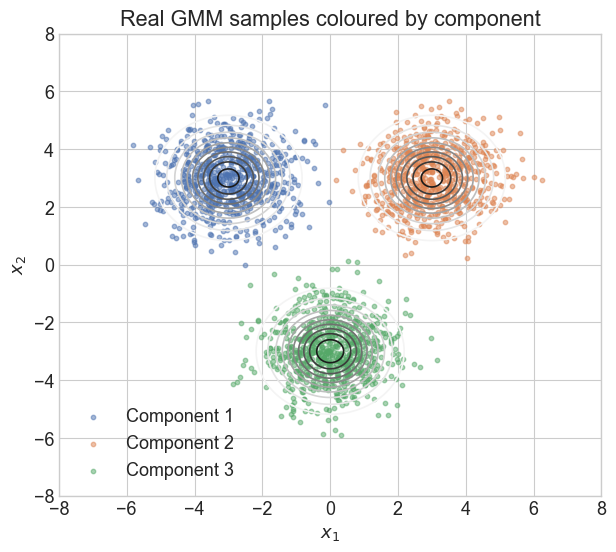

In [85]:
xs = np.linspace(-8, 8, 400)
ys = np.linspace(-6, 6, 300)
cmap = plt.get_cmap("Paired", len(mus_r))
Z_real = gmm_pdf_grid(xs, ys, mus_r, Sig_r, w_r)

plt.figure(figsize=(7,6))


for k in range(len(mus_r)):
    idx = labels_real == k
    plt.scatter(
        x_real[idx, 0],
        x_real[idx, 1],
        s=10,
        alpha=0.5,
        label=f"Component {k+1}",
        color=palette[k]
    )
plt.contour(xs, ys, Z_real, levels=12, linewidths=1.2)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.xlim((-8,8))
plt.ylim((-8,8))
plt.title("Real GMM samples coloured by component")
plt.legend()
plt.show()

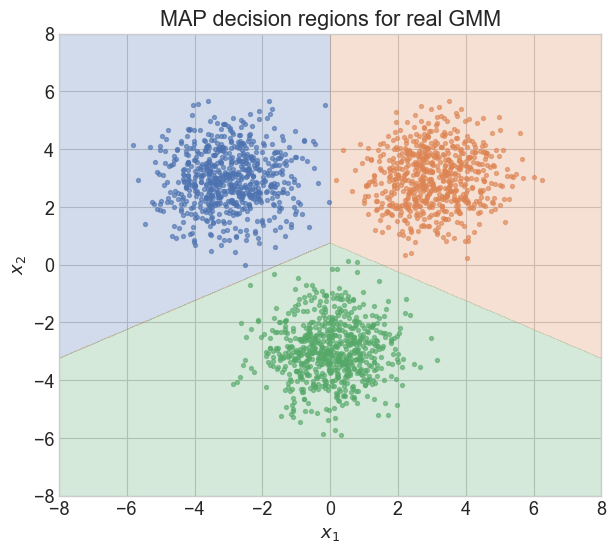

In [86]:
xs = np.linspace(-8, 8, 500)
ys = np.linspace(-8, 8, 500)

regions = map_regions(xs, ys, mus_r, Sig_r, w_r)

plt.figure(figsize=(7, 6))

palette = sns.color_palette("deep", len(mus_r))
cmap = ListedColormap(palette)
plt.contourf(xs, ys, regions, levels=len(mus_r)-1, alpha=0.25, cmap=cmap)
for k in range(len(mus_r)):
    idx = labels_real == k
    plt.scatter(
        x_real[idx, 0],
        x_real[idx, 1],
        s=8,
        alpha=0.6,
        color=palette[k]
    )

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("MAP decision regions for real GMM")
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.show()
